In [ ]:
import numpy as np

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from scripts.population_averages_perday import long_var
from tqdm.notebook import tqdm
import scipy.signal
import pynapple as nap

import pandas as pd
import scipy.io as spio
import os

from totalsync_utils import decode_b64_files

In [ ]:
pin_sheet_file = '/Users/fpbattaglia/src/ofl_2p_analysis/docs/pinSheet.json'
Path_non_decoded_files = "/Users/fpbattaglia/Dropbox/Data/ofl_2p/Totalsync/477116"
s3d_results_folder = "/Users/fpbattaglia/Dropbox/Data/s3d-results-00003whole_test-std"


In [ ]:
b64_files = sorted(Path(Path_non_decoded_files).glob("*.b64"))
b64_files = sorted(str(p) for p in Path(Path_non_decoded_files).glob("*.b64"))

In [ ]:
tsync_file = b64_files[2]
tsync_session = Path(tsync_file).stem

results_pins = decode_b64_files(Path_non_decoded_files, pin_json_path=pin_sheet_file)


In [15]:
tsync_data = results_pins[tsync_session]

In [16]:
tsync_data.keys()

dict_keys(['startTS', 'transmitTS', 'longVar', 'packetNums', 'GND', 'Wheel Encoder A', 'Wheel Encoder B', 'Wheel Encoder X(check)', 'Wheel Encoder Z(check)', 'Scanner Frame Clock (Input)', 'Finish Trial', 'Reward Tile', 'City Environment', 'Nature Environment', 'Halloween Environment', 'Tunnel 1', 'Tunnel 2', 'New Trial', 'Valve Toggle', 'Barcode (Scanner)', 'OFL Experiment', 'Shock Grid', 'Pre-Shock Experiment', 'Test Shock', 'Ephys Trigger', 'Pin Sync LED', 'Trigger C', 'Lick Detection', 'Breathing Sensor'])

In [24]:
frame_clock = tsync_data['Scanner Frame Clock (Input)'].astype(int)

log_times = tsync_data['startTS'].astype(int)
onsets = np.nonzero(np.diff(frame_clock) == 1)[0]+1

In [18]:
tsync_data['startTS']

array([ 11948993,  11949993,  11950993, ..., 311931470, 311932470,
       311933470], shape=(624348,), dtype=uint32)

(100000.0, 100300.0)

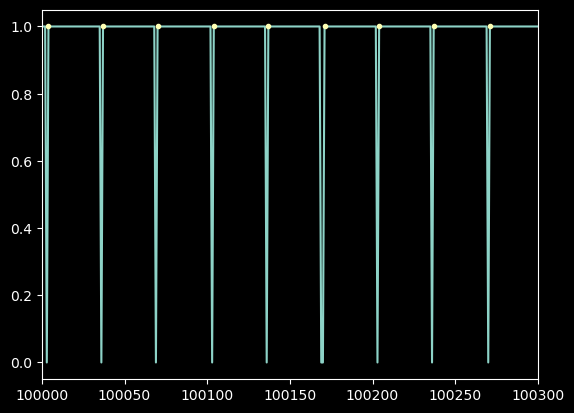

In [20]:
(fig, ax) = plt.subplots()
ax.plot(frame_clock)
ax.plot(onsets, np.ones_like(onsets), '.')
ax.set_xlim(100000, 100300)

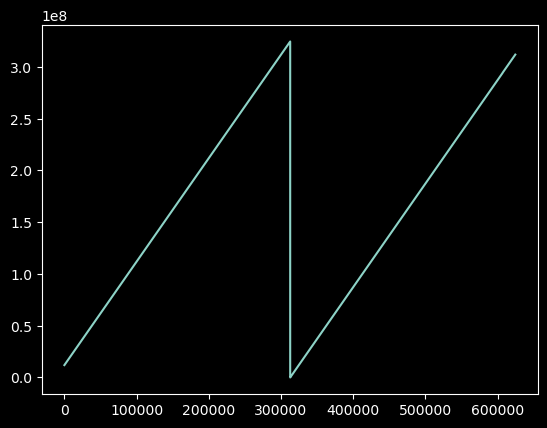

In [21]:
(fig, ax) = plt.subplots()
ax.plot(log_times)

In [65]:
def fix_tsync_time(log_times: np.ndarray):
	skips = - np.where(np.diff(log_times) < 0, np.diff(log_times) - np.median(np.diff(log_times)), 0)
	cs = np.cumsum(skips)
	cs2 = np.hstack((0, cs))
	tsync_time = log_times + cs2
	return tsync_time

In [66]:
tsync_time = fix_tsync_time(log_times)

In [72]:
t_frames = tsync_time[onsets]

In [73]:
long_var = tsync_data['longVar']

In [74]:
long_var

array([[    4,     0,     0, ...,     0,     0,   182],
       [    4,     0,     0, ...,     0,     0,   182],
       [    4,     0,     0, ...,     0,     0,   182],
       ...,
       [12172,   742,     0, ...,     0,     0,   181],
       [12172,   742,     0, ...,     0,     0,   181],
       [12172,   742,     0, ...,     0,     0,   181]],
      shape=(624348, 8), dtype=uint32)

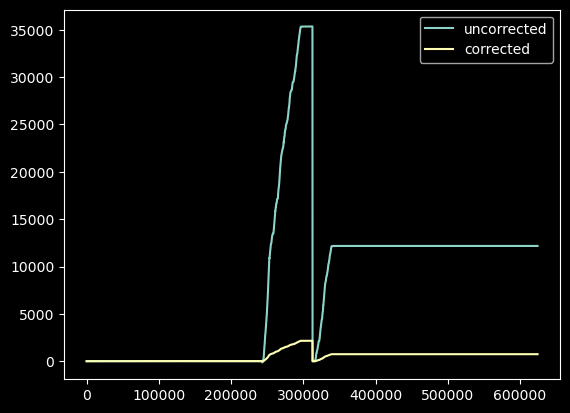

In [82]:
(fig, ax) = plt.subplots()
ax.plot(long_var[:, 0].astype(np.int32))
ax.plot(long_var[:, 1].astype(np.int32))
ax.legend(('uncorrected', 'corrected'))

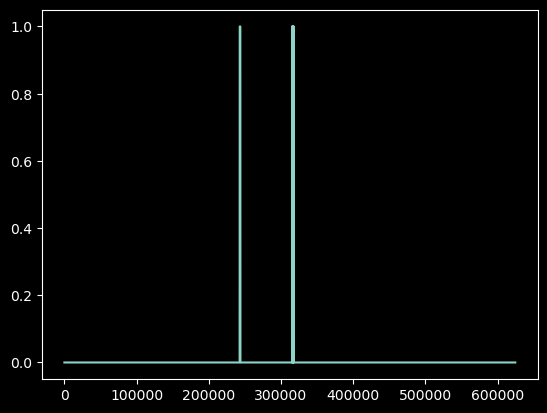

In [83]:
(fig, ax) = plt.subplots()
ax.plot(long_var[:, 2].astype(np.int32))